In [1]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut

# generate true Us

In [9]:
Us = sim.generate_Us(s=24,k=16,p=40,type='hard')

# Generate Vtrain

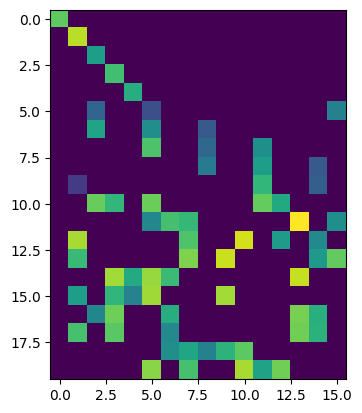

In [10]:
def generate_V(n_tasks, n_parcels, seed=None):
    if seed is not None:
        np.random.seed(seed)
    V = np.zeros((n_tasks, n_parcels))

    for task in range(n_tasks):
        if task < 5 and task < n_tasks:
            # Activate a distinct parcel for each task with strong activation
            parcel = task % n_parcels  # Ensure parcel index is within bounds
            V[task, parcel] = 1.0 + np.random.uniform(-0.3, 0.3)  # Add noise

        elif 5 <= task < 10 and task < n_tasks:
            # Activate three parcels with decreasing strengths
            parcel_1 = (task * 3) % n_parcels
            parcel_2 = (parcel_1 + 3) % n_parcels
            parcel_3 = (parcel_2 + 3) % n_parcels
            V[task, [parcel_1, parcel_2, parcel_3]] = [
                0.8 + np.random.uniform(-0.3, 0.3),
                0.6 + np.random.uniform(-0.3, 0.3),
                0.4 + np.random.uniform(-0.3, 0.3)
            ]
        else:
            # Randomly activate five parcels with unique patterns
            active_parcels = np.random.choice(n_parcels, size=5, replace=False)
            base_strength = 0.7
            for i, parcel in enumerate(active_parcels):
                V[task, parcel] = base_strength + (0.2 * i) + np.random.uniform(-0.2, 0.2)
                base_strength -= 0.1
    return V

V = generate_V(n_tasks=20, n_parcels = 16, seed=1)

# Visualize the V matrix
plt.imshow(V)




In [13]:
# check if singular matrix
print(np.linalg.matrix_rank(V))

16


# Generate data

In [14]:
# get the data no nooise
y = V @ Us

# add noise to data
noise_std = 0.1
noise = np.random.normal(loc=0.0, scale=noise_std, size=y.shape)
y_noisy = y + noise


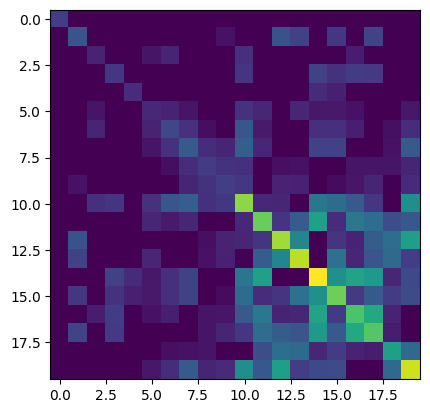

In [15]:
test = V @ V.T
plt.imshow(test)

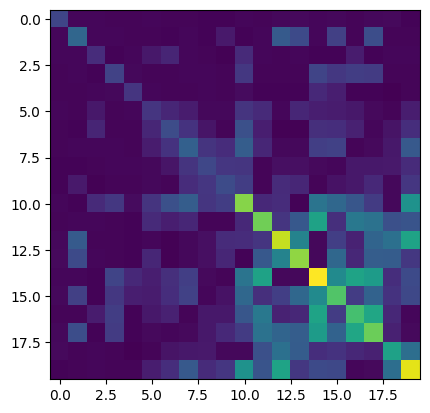

In [16]:
cov_lsit = []
for i in range(y.shape[0]):
    cov = y_noisy[i] @ y_noisy[i].T
    cov_lsit.append(cov)
cov_matrix = np.stack(cov_lsit, axis=0)
cov_matrix = np.mean(cov_matrix, axis=0)

plt.imshow(cov_matrix)

# Test different methods to estimate Us based on non noisy data

In [17]:
# test different methos
U_hat_ols = sim.estimate_Us_ols(y, V)
U_hat_NNLS = sim.estimate_Us_NNLS(y, V,max_iter=1000, tol=1e-6, learning_rate=1e-3)
U_hat_l2 = sim.estimate_Us_l2_regularization(y, V, alpha=0.1, max_iter=1000, tol=1e-6, learning_rate=1e-3)

In [18]:
mse_per_subject = np.zeros(Us.shape[0])
for subj in range(Us.shape[0]):
    mse = np.mean((Us[subj] - U_hat_ols[subj]) ** 2)
    mse_per_subject[subj] = mse
print("Average MSE ols across subjects:", np.mean(mse_per_subject))


Average MSE ols across subjects: 4.7729027141211566e-29


In [19]:
mse_per_subject = np.zeros(Us.shape[0])
for subj in range(Us.shape[0]):
    mse = np.mean((Us[subj] - U_hat_NNLS[subj]) ** 2)
    mse_per_subject[subj] = mse

print("Average MSE NNLS across subjects:", np.mean(mse_per_subject))

Average MSE NNLS across subjects: 0.004584908625910191


In [20]:
mse_per_subject = np.zeros(Us.shape[0])
for subj in range(Us.shape[0]):
    mse = np.mean((Us[subj] - U_hat_l2[subj]) ** 2)
    mse_per_subject[subj] = mse

print("Average MSE L2 across subjects:", np.mean(mse_per_subject))

Average MSE L2 across subjects: 0.0056012057693661035


# Test different methods to estimate Us based on noisy data

In [21]:
# test different methos
U_hat_ols = sim.estimate_Us_ols(y_noisy, V)
U_hat_NNLS = sim.estimate_Us_NNLS(y_noisy, V,max_iter=1000, tol=1e-6, learning_rate=1e-3)
U_hat_l2 = sim.estimate_Us_l2_regularization(y_noisy, V, alpha=0.1, max_iter=1000, tol=1e-6, learning_rate=1e-3)

In [22]:
mse_per_subject = np.zeros(Us.shape[0])
for subj in range(Us.shape[0]):
    mse = np.mean((Us[subj] - U_hat_ols[subj]) ** 2)
    mse_per_subject[subj] = mse
print("Average MSE ols across subjects:", np.mean(mse_per_subject))


Average MSE ols across subjects: 0.07719058585272069


In [23]:
mse_per_subject = np.zeros(Us.shape[0])
for subj in range(Us.shape[0]):
    mse = np.mean((Us[subj] - U_hat_NNLS[subj]) ** 2)
    mse_per_subject[subj] = mse

print("Average MSE NNLS across subjects:", np.mean(mse_per_subject))

Average MSE NNLS across subjects: 0.006264979390456827


In [24]:
mse_per_subject = np.zeros(Us.shape[0])
for subj in range(Us.shape[0]):
    mse = np.mean((Us[subj] - U_hat_l2[subj]) ** 2)
    mse_per_subject[subj] = mse

print("Average MSE L2 across subjects:", np.mean(mse_per_subject))

Average MSE L2 across subjects: 0.007163048692490448


# construct V test / Y test

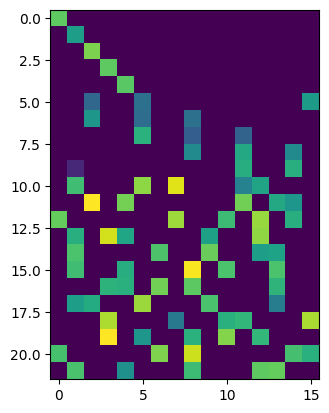

In [27]:
V_test = generate_V(n_tasks=22, n_parcels = 16, seed=2)
plt.imshow(V_test)


In [28]:
Y_test = V_test @ Us
noise_std = 1
noise = np.random.normal(loc=0.0, scale=noise_std, size=Y_test.shape)
Y_test_noisy = Y_test + noise

# cosine similarity

In [32]:
# make into tensors
Y_test = pt.tensor(Y_test, dtype=pt.float32)
V_test = pt.tensor(V_test, dtype=pt.float32)
Y_test_noisy = pt.tensor(Y_test_noisy, dtype=pt.float32)
Us = pt.tensor(Us, dtype=pt.float32)
U_hat_ols = pt.tensor(U_hat_ols, dtype=pt.float32)
U_hat_NNLS = pt.tensor(U_hat_NNLS, dtype=pt.float32)
U_hat_l2 = pt.tensor(U_hat_l2, dtype=pt.float32)


C:\Users\barafat\AppData\Local\Temp\ipykernel_20452\542260152.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_test = pt.tensor(Y_test, dtype=pt.float32)
C:\Users\barafat\AppData\Local\Temp\ipykernel_20452\542260152.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  V_test = pt.tensor(V_test, dtype=pt.float32)
C:\Users\barafat\AppData\Local\Temp\ipykernel_20452\542260152.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Us = pt.tensor(Us, dtype=pt.float32)
C:\Users\barafat\AppData\Local\Temp\ipykernel_20452\542260152.py:6: UserWar

In [33]:
cos = ev.cosine_error(Y_test_noisy, V_test, U_hat_ols,adjusted= False, type='expected')
print("Cosine error ols:", cos.mean())

cos = ev.cosine_error(Y_test_noisy, V_test, U_hat_NNLS,adjusted= False, type='expected')
print("Cosine error NNLS:", cos.mean())

cos = ev.cosine_error(Y_test_noisy, V_test, U_hat_l2,adjusted= False, type='expected')
print("Cosine error L2:", cos.mean())


Cosine error ols: tensor(0.6218)
Cosine error NNLS: tensor(0.6582)
Cosine error L2: tensor(0.6706)


# Now do this on different task batteries

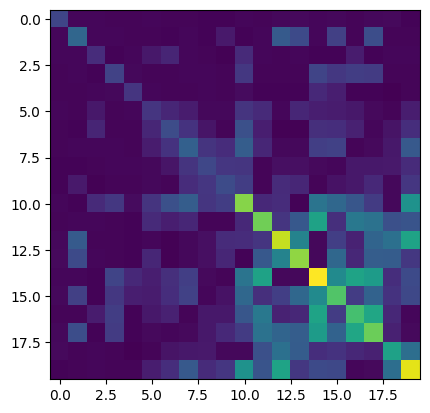

In [34]:
cov_lsit = []
for i in range(y.shape[0]):
    cov = y_noisy[i] @ y_noisy[i].T
    cov_lsit.append(cov)
cov_matrix = np.stack(cov_lsit, axis=0)
cov_matrix = np.mean(cov_matrix, axis=0)

plt.imshow(cov_matrix)

In [65]:
D = ut.build_combinations(cov_matrix, strategy='random',n_iter=30,n_tasks=4,seed=1)

In [66]:
counter = 0
def evaluate_cos(combination):
    global counter
    counter += 1
    print("Iteration:", counter)
    vtrain = V[combination]
    ytrain = y_noisy[:,combination,:]

    U_hat_NNLS = sim.estimate_Us_NNLS(ytrain, vtrain,max_iter=100, tol=1e-6, learning_rate=1e-3)

    ytest = Y_test_noisy
    vtest = V_test

    U_hat_NNLS = pt.tensor(U_hat_NNLS, dtype=pt.float32)
    ytest = pt.tensor(ytest, dtype=pt.float32)
    vtest = pt.tensor(vtest, dtype=pt.float32)

    cos = ev.cosine_error(ytest, vtest, U_hat_NNLS,adjusted= False, type='expected')

    return cos.mean().numpy()

    


In [67]:
unique_combinations_df = D[D['offset'] == D['offset'].min()].copy()
unique_combinations_df['cos'] = unique_combinations_df['combination'].apply(evaluate_cos)

Iteration: 1


C:\Users\barafat\AppData\Local\Temp\ipykernel_20452\1004239768.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ytest = pt.tensor(ytest, dtype=pt.float32)
C:\Users\barafat\AppData\Local\Temp\ipykernel_20452\1004239768.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  vtest = pt.tensor(vtest, dtype=pt.float32)


Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30


In [68]:
D['combination'] = D['combination'].apply(tuple)
unique_combinations_df['combination'] = unique_combinations_df['combination'].apply(tuple)

# Now perform the merge operation using the tuple values
D = D.merge(
    unique_combinations_df[['combination', 'cos']], 
    on='combination', 
    how='left'
)

In [69]:
A = D[D['offset'] == 0.001].copy()

In [72]:
# get the two variables for Dcbc and log_det
log_det_list = A['log_det'].values
dcbc_list = A['cos'].values

from scipy.stats import pearsonr
r_value, p_value = pearsonr(log_det_list, dcbc_list)

print(f"Correlation between log_det and cos: {r_value}, p-value: {p_value}")

Correlation between log_det and cos: -0.3774475181584806, p-value: 0.039755267967736034


In [73]:
# get the two variables for DCBC and min_est
min_est_list = A['min_est'].values
dcbc_list = A['cos'].values

r_value, p_value = pearsonr(min_est_list, dcbc_list)

print(f"Correlation between min_est and cos: {r_value}, p-value: {p_value}")

Correlation between min_est and cos: 0.1803339229068667, p-value: 0.34028180443391964


In [74]:
# get the two variables for DCBC and max_var
max_var_list = A['max_var'].values
dcbc_list = A['cos'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and cos: {r_value}, p-value: {p_value}")

Correlation between max_var and cos: -0.8795611161649394, p-value: 1.561702942157151e-10


In [75]:
# get the two variables for DCBC and max_var
max_var_list = A['off_diag'].values
dcbc_list = A['cos'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and cos: {r_value}, p-value: {p_value}")

Correlation between max_var and cos: -0.4647664221915216, p-value: 0.009663673398751134


#